# LeetCode #82: Remove Duplicates from Sorted List II

https://leetcode.com/problems/remove-duplicates-from-sorted-list-ii/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Copy unique values | O(n) | O(n) | Collect values that appear once, rebuild |
| **Dummy Head + Skip ★** | **O(n)** | **O(1)** | prev pointer skips entire duplicate runs |

---

## Understanding the Methods

### Brute Force (Extra Array)
Scan list, count occurrences (or check neighbors in sorted list), collect unique-only values, rebuild list. O(n) but O(n) space.

### Optimal: Dummy Head + Skip ★
Use a dummy node before head so prev always has something to point from.

For each node curr:
- If curr.val == curr.next.val → duplicate run detected. Advance curr through all matching values. Set prev.next = curr (skip entire run).
- Otherwise → unique node. Advance prev to curr, then curr to curr.next.

Return dummy.next.

**Constraints:**
* Number of nodes: [0, 300]
* Node values: [-100, 100]
* List is sorted in ascending order

## Solutions

### C#

In [ ]:
public class Solution {
    public ListNode DeleteDuplicates(ListNode head) {
        var dummy = new ListNode(0, head);
        var prev = dummy;
        var curr = head;

        while (curr != null) {
            bool isDup = curr.next != null && curr.val == curr.next.val;
            if (isDup) {
                int val = curr.val;
                while (curr != null && curr.val == val)
                    curr = curr.next;
                prev.next = curr; // skip entire duplicate run
            } else {
                prev = curr;
                curr = curr.next;
            }
        }

        return dummy.next;
    }
}

### Python

In [ ]:
class Solution:
    def deleteDuplicates(self, head):
        dummy = ListNode(0, head)
        prev = dummy
        curr = head

        while curr:
            is_dup = curr.next and curr.val == curr.next.val
            if is_dup:
                val = curr.val
                while curr and curr.val == val:
                    curr = curr.next
                prev.next = curr  # skip entire run
            else:
                prev = curr
                curr = curr.next

        return dummy.next

### Go

In [ ]:
func deleteDuplicates(head *ListNode) *ListNode {
    dummy := &ListNode{Next: head}
    prev := dummy
    curr := head

    for curr != nil {
        isDup := curr.Next != nil && curr.Val == curr.Next.Val
        if isDup {
            val := curr.Val
            for curr != nil && curr.Val == val {
                curr = curr.Next
            }
            prev.Next = curr
        } else {
            prev = curr
            curr = curr.Next
        }
    }

    return dummy.Next
}

### Rust

In [ ]:
impl Solution {
    pub fn delete_duplicates(head: Option<Box<ListNode>>) -> Option<Box<ListNode>> {
        let mut dummy = Box::new(ListNode { val: 0, next: head });
        let mut prev = &mut dummy as *mut Box<ListNode>;

        unsafe {
            let mut curr = (*prev).next.as_mut().map(|n| n as *mut Box<ListNode>);
            while let Some(c) = curr {
                let is_dup = (*c).next.as_ref()
                    .map_or(false, |n| n.val == (*c).val);
                if is_dup {
                    let val = (*c).val;
                    while (*prev).next.as_ref().map_or(false, |n| n.val == val) {
                        (*prev).next = (*prev).next.take().and_then(|n| n.next);
                    }
                    curr = (*prev).next.as_mut().map(|n| n as *mut Box<ListNode>);
                } else {
                    prev = (*prev).next.as_mut().unwrap() as *mut Box<ListNode>;
                    curr = (*prev).next.as_mut().map(|n| n as *mut Box<ListNode>);
                }
            }
        }
        dummy.next
    }
}

## Example Scenarios

### 1. Common Case — Duplicates in the Middle
**Input:** `1 \to 2 \to 3 \to 3 \to 4 \to 4 \to 5`

prev walks from dummy to 1 to 2 (unique nodes). At node 3, `curr.val == curr.next.val` triggers the skip loop: advance past both 3s, set `prev.next = 4`. Same for the 4s. Result: $1 \to 2 \to 5$.

**Why it’s useful:** Exercises both the unique-advance path and the duplicate-skip path in one traversal.

### 2. Slightly Complex — Duplicates at Head AND Tail
**Input:** `1 \to 1 \to 2 \to 3 \to 3`

Without a dummy node, removing head duplicates requires special logic. The dummy node unifies all cases: `prev = dummy`, skip all 1s $\Rightarrow$ `dummy.next = 2`. Then skip all 3s $\Rightarrow$ `prev.next = null`. Result: $2$.

**Why it’s tricky:** Head duplicates change the return value from `head` to a later node. The dummy pattern avoids separate head-handling code.

### 3. Edge Case: Time Factor — 300 Nodes, All Pairs
**Input:** `1 \to 1 \to 2 \to 2 \to \ldots \to 150 \to 150` (300 nodes, 150 pairs)

Every value appears exactly twice. The outer loop runs 150 iterations, each inner skip loop advances 2 nodes. Total node visits: 300 (each exactly once). Result: empty list (null).

**Why it’s tricky:** Maximum node count ($n = 300$). Confirms $O(n)$ — the inner and outer loops together visit each node once.

### 4. Edge Case: Space Factor — Empty List
**Input:** `head = null`

dummy = ListNode(0, null). curr = null $\Rightarrow$ while loop body never executes. Return dummy.next = null. Only 1 dummy node + 2 pointers allocated.

**Why it’s tricky:** $O(1)$ space regardless of input. No hash maps, no arrays. The algorithm works purely with pointer manipulation.

### 5. Almost-Impossible but Plausible — 300 Identical Nodes
**Input:** `(-100) \to (-100) \to \ldots \to (-100)` (300 nodes, all value $-100$)

One massive duplicate run. The inner `while curr and curr.val == val` loop runs 300 times in a single shot, advancing curr to null. Then `prev.next = null`. Result: empty list.

**Why it’s tricky:** The inner loop must handle curr becoming null (end of list) without null-pointer errors. Uses the minimum allowed value ($-100$) to test negative boundary. The entire list is one duplicate group.


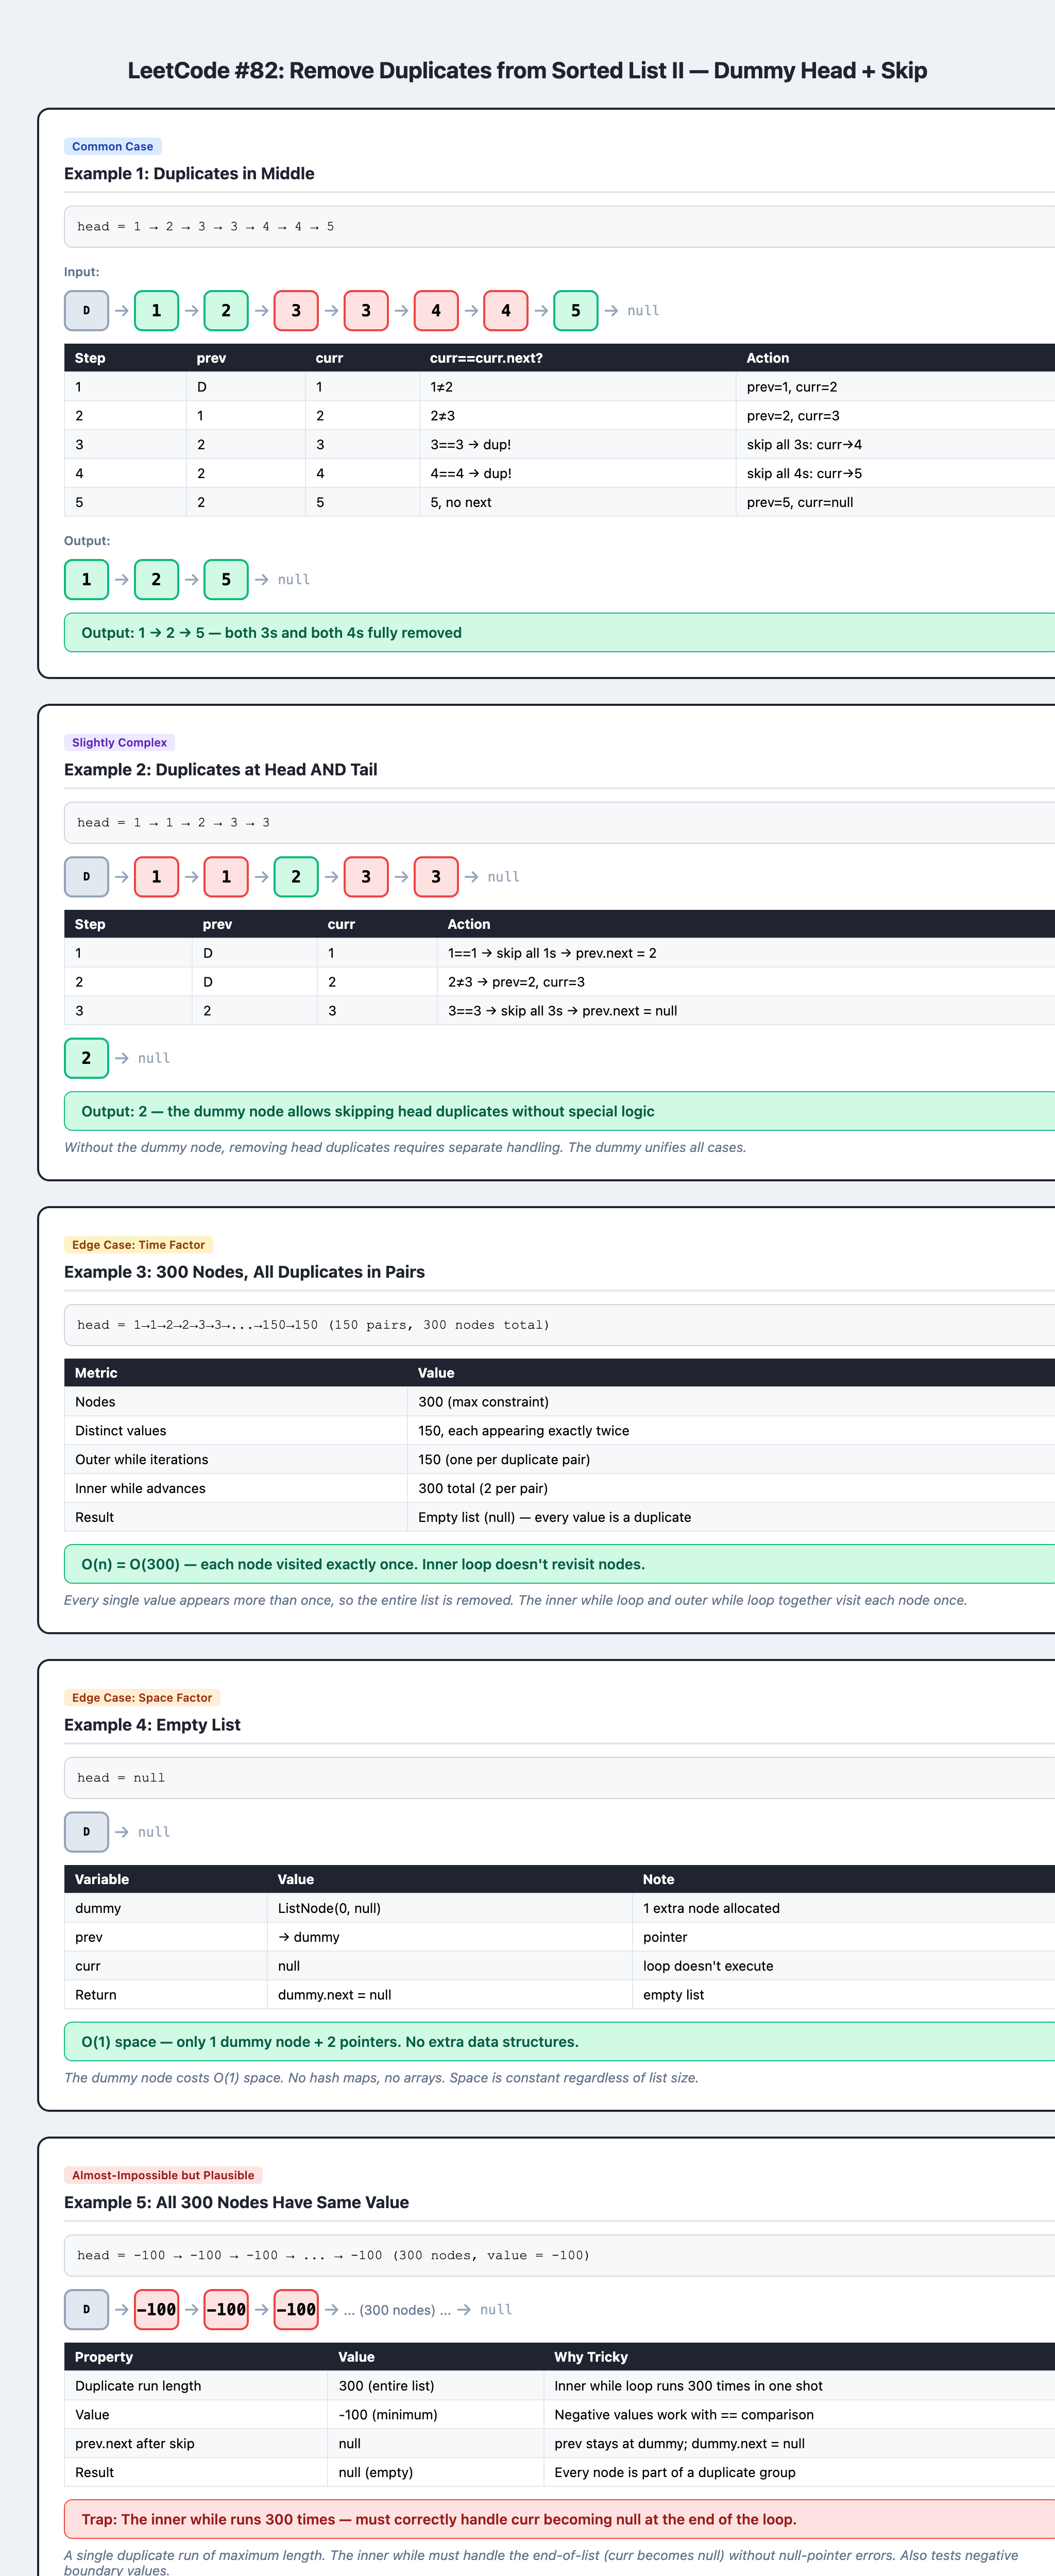